In [1]:
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from spbu_bachelor_thesis.nn.kan import BaselineKAN
from spbu_bachelor_thesis.nn.mlp import BaselineMLP
from spbu_bachelor_thesis.nn.architectural_kan import ArchitecturalKAN
from spbu_bachelor_thesis.nn.regularized_kan import EWCLoss
from spbu_bachelor_thesis.nn.rehearsal_kan import RehearsalKAN
from spbu_bachelor_thesis.datasets import EmbeddingDataset
from spbu_bachelor_thesis.global_constants import MODELS_DIR
from spbu_bachelor_thesis.train_test import train_offline, measure_forward_backward_time


# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cuda')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

#### Datasets and training parameters

In [3]:
# Offline training parameters
learning_rate = 8e-4
batch_size = 128
criterion = nn.CrossEntropyLoss()
num_epochs = 100
early_stopping = 10

# Precomputed elmbeddings of images from the CUB200 dataset generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

#### Models definition

###### MLP:

In [4]:
baseline_mlp = BaselineMLP()
mlp_optimizer = torch.optim.NAdam(baseline_mlp.parameters(), lr=learning_rate)
baseline_mlp

BaselineMLP(
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=200, bias=True)
  )
)

###### KAN:

In [5]:
baseline_kan = BaselineKAN()
kan_optimizer = torch.optim.NAdam(baseline_kan.parameters(), lr=learning_rate)
baseline_kan

BaselineKAN(
  (classifier): Sequential(
    (0): KANLayer(
      (bn): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): KANLayer(
      (bn): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
)

###### Architectural KAN:

In [6]:
architectural_kan = ArchitecturalKAN()
architectural_kan

ArchitecturalKAN(
  (classifier): Sequential(
    (0): KANLayer(
      (bn): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): FELLayer()
    (2): KANLayer(
      (bn): BatchNorm1d(3000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
)

###### Regularized KAN:

In [6]:
# The regularized KAN model is the same as the BaselineKAN, but custom loss
# functions is used. The regularization is not applied to the first study session,
# so there will be no difference between regularized KAN and normal KAN in offline
# training.

###### Rehearsal KAN:

In [8]:
rehearsal_kan = RehearsalKAN()
rehearsal_kan

RehearsalKAN(
  (som): SOMLayer(
    (fl): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): KANLayer(
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

#### Calculation of trainable parameters number

###### MLP:

In [ ]:
num_mlp_params = sum(p.numel() for p in baseline_mlp.parameters() if p.requires_grad)
print(f"Number of trainable parameters in BaselineMLP: {num_mlp_params}")

Number of trainable parameters in BaselineMLP: 1060200


###### KAN:

In [ ]:
num_kan_params = sum(p.numel() for p in baseline_kan.parameters() if p.requires_grad)
print(f"Number of trainable parameters in BaselineKAN: {num_kan_params}")

Number of trainable parameters in BaselineKAN: 6299296


#### Offline training

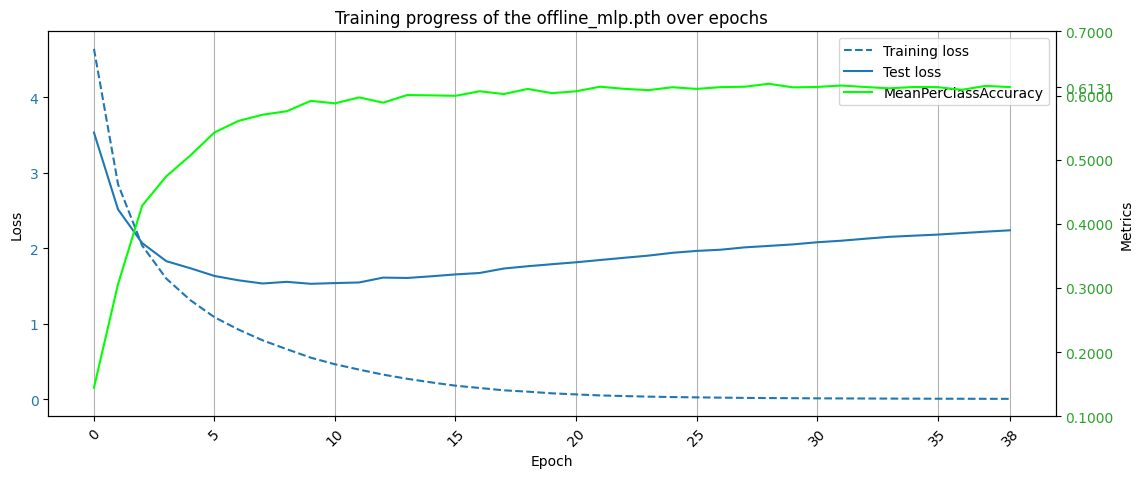

Early stopping is triggered at the epoch 38.
Best metric's value: 0.61833.
The model's weights are saved to /root/spbu-bachelor-thesis/models/offline_mlp.pth


In [ ]:
train_offline(
    model=baseline_mlp,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=mlp_optimizer,
    save_path="offline_baseline_mlp.pth",
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

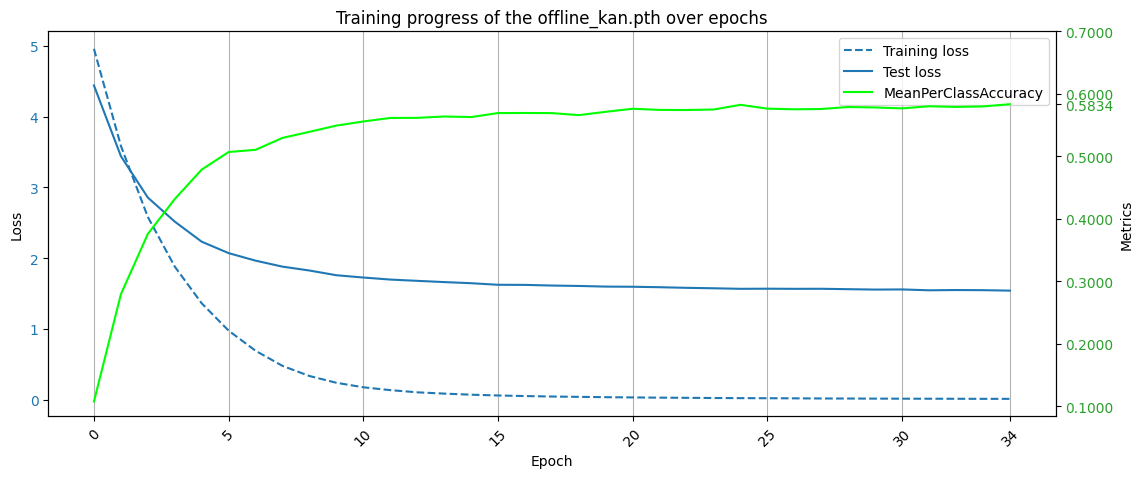

Early stopping is triggered at the epoch 34.
Best metric's value: 0.58245.
The model's weights are saved to /root/spbu-bachelor-thesis/models/offline_kan.pth


In [ ]:
train_offline(
    model=baseline_kan,
    trainloader=trainloader,
    testloader=testloader,
    criterion=criterion,
    optimizer=kan_optimizer,
    save_path="offline_baseline_kan.pth",
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

#### Forward/backward pass benchmark

In [11]:
forward, backward = measure_forward_backward_time(BaselineMLP, out_features=1024)
print(f"Forward pass time in miliseconds: {forward * 1000};")
print(f"Backward pass time in miliseconds: {backward * 1000};")

Backward pass: 100%|██████████| 100/100 [00:22<00:00,  4.35it/s]

Forward pass time in miliseconds: 75.04487336000238;
Backward pass time in miliseconds: 154.90233953999905;


In [12]:
forward, backward = measure_forward_backward_time(BaselineKAN, out_features=1024)
print(f"Forward pass time in miliseconds: {forward * 1000};")
print(f"Backward pass time in miliseconds: {backward * 1000};")

Forward pass:  91%|█████████ | 91/100 [01:52<00:11,  1.23s/it]


KeyboardInterrupt: 